# SMOTE strategy: 

Create artifical data to balance target classes
we might get good evaluation metrics here, but we have to check the counterfactuals...

## load

In [1]:
import os
from pathlib import Path
import joblib

from dotenv import load_dotenv
import pandas as pd

In [2]:
load_dotenv()

DATA_DIR = Path(os.getenv("DATA_DIR"))
MODELS_DIR = Path(os.getenv("MODELS_DIR"))
TRAINING_PATH = DATA_DIR / "eta.csv"
TEST_PATH = DATA_DIR / "ete.csv"

print(DATA_DIR)
print(TRAINING_PATH)
print(TEST_PATH)

print(DATA_DIR.is_dir())
print(MODELS_DIR.is_dir())

print(TRAINING_PATH.is_file())
print(TEST_PATH.is_file())

/home/dyretna/Dokument/Code/GitHub/nightingale_projects/cf_bench/data
/home/dyretna/Dokument/Code/GitHub/nightingale_projects/cf_bench/data/eta.csv
/home/dyretna/Dokument/Code/GitHub/nightingale_projects/cf_bench/data/ete.csv
True
True
True
True


In [3]:
train_df = pd.read_csv(TRAINING_PATH).drop(columns=["Unnamed: 0"], errors="ignore")
test_df = pd.read_csv(TEST_PATH).drop(columns=["Unnamed: 0"], errors="ignore")

In [11]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32883 entries, 0 to 32882
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   etfruit   32883 non-null  int64  
 1   eatveg    32883 non-null  int64  
 2   cgtsmok   32883 non-null  int64  
 3   alcfreq   32883 non-null  int64  
 4   slprl     32883 non-null  int64  
 5   paccnois  32883 non-null  int64  
 6   bmi       32883 non-null  float64
 7   dosprt    32883 non-null  int64  
 8   hltprhc   32883 non-null  int64  
dtypes: float64(1), int64(8)
memory usage: 2.3 MB


In [12]:
train_df.head(5)

,etfruit,eatveg,cgtsmok,alcfreq,slprl,paccnois,bmi,dosprt,hltprhc
0,3,3,6,5,1,0,21.453287,2,0
1,6,3,2,2,4,0,25.181077,7,0
2,4,1,3,2,2,0,23.529412,5,0
3,5,4,4,2,3,0,30.487805,2,0
4,4,4,2,2,2,0,26.769780,2,0


In [4]:
TARGET = "hltprhc"

X_train = train_df.drop(TARGET, axis=1)
y_train = train_df[TARGET]

X_test = test_df.drop(TARGET, axis=1)
y_test = test_df[TARGET]

print(X_train.shape)
print(X_test.shape)

(32883, 8)
(8221, 8)


### SMOTE

In [5]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

In [6]:
import matplotlib.pyplot as plt

def plot_target_distribution(y_before, y_after, label):
    fig, ax = plt.subplots(figsize=(8, 5))

    before_counts = y_before.value_counts().sort_index()
    after_counts = y_after.value_counts().sort_index()

    x = range(len(before_counts))
    width = 0.35

    ax.bar([i - width/2 for i in x], before_counts.values, width, label='Before', alpha=0.8)
    ax.bar([i + width/2 for i in x], after_counts.values, width, label='After', alpha=0.8)

    ax.set_xlabel("Class")
    ax.set_ylabel("Count")
    ax.set_title(f"Distribution of {label}")
    ax.set_xticks(x)
    ax.set_xticklabels(before_counts.index)
    ax.legend()

    plt.tight_layout()
    plt.show()


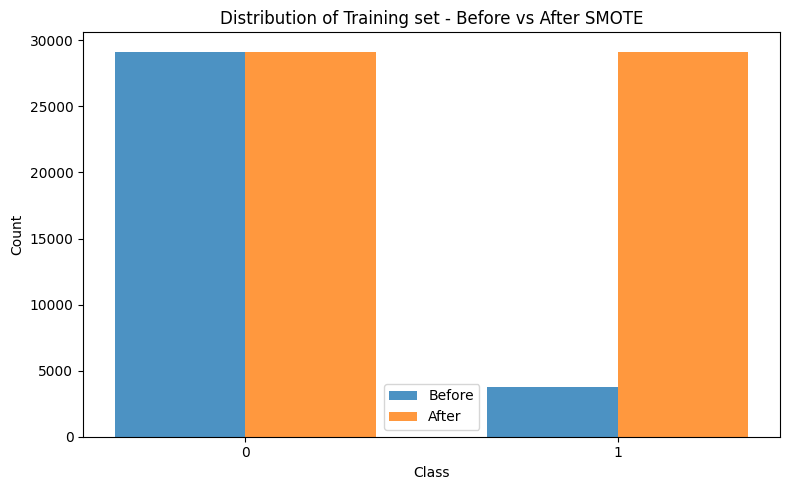

In [7]:
plot_target_distribution(y_train, y_train_res, label="Training set - Before vs After SMOTE")

### Train with SMOTE inside Gridsearch Pipeline

this is to prevent leakage, scikit will handle SMOTE

In [15]:
from imblearn.pipeline import Pipeline # Use Imblearns pipeline!
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from scipy.stats import randint

In [27]:
# First run:
# n_iter = 200, cv=5
# scoring f1-macro
params_first_wide = {
    "rf__n_estimators":     randint(150, 600),
    "rf__max_depth":        randint(3, 16),
    "rf__min_samples_split":randint(2, 10),
    "rf__min_samples_leaf": randint(1, 6),
    "rf__max_features":     ["sqrt", "log2", None],
    "rf__criterion":        ["gini", "entropy", "log_loss"],
    "rf__bootstrap":        [True],
    "rf__class_weight":     [None],
}

# second:
# n_iter = 200, cv=5
# scoring f1-macro
params_second = {
    "rf__n_estimators":     randint(150, 600),
    "rf__max_depth":        randint(12, 16),
    "rf__min_samples_split":randint(3, 9),
    "rf__min_samples_leaf": randint(1, 5),
    "rf__max_features":     ["sqrt"],
    "rf__criterion":        ["gini", "entropy"],
    "rf__bootstrap":        [True],
    "rf__class_weight":     [None],
}


In [28]:
pipeline = Pipeline([
    ("smote", SMOTE(random_state=42)),
    ("rf", RandomForestClassifier())
])


rand = RandomizedSearchCV(
    pipeline,
    param_distributions=params_second,
    n_iter=200,
    scoring="f1_macro",
    n_jobs=-1,
    cv=5,
    verbose=2,
    random_state=42,
)
rand.fit(X_train, y_train)


print("RandomizedSearch Done. best score (cv):", rand.best_score_)
print("Best parameters:")
print(rand.best_params_)



Fitting 5 folds for each of 200 candidates, totalling 1000 fits
[CV] END rf__bootstrap=True, rf__class_weight=None, rf__criterion=gini, rf__max_depth=15, rf__max_features=sqrt, rf__min_samples_leaf=1, rf__min_samples_split=5, rf__n_estimators=221; total time=   7.9s
[CV] END rf__bootstrap=True, rf__class_weight=None, rf__criterion=gini, rf__max_depth=15, rf__max_features=sqrt, rf__min_samples_leaf=1, rf__min_samples_split=5, rf__n_estimators=221; total time=   7.9s
[CV] END rf__bootstrap=True, rf__class_weight=None, rf__criterion=gini, rf__max_depth=15, rf__max_features=sqrt, rf__min_samples_leaf=1, rf__min_samples_split=5, rf__n_estimators=221; total time=   8.1s
[CV] END rf__bootstrap=True, rf__class_weight=None, rf__criterion=gini, rf__max_depth=15, rf__max_features=sqrt, rf__min_samples_leaf=1, rf__min_samples_split=5, rf__n_estimators=221; total time=   8.3s
[CV] END rf__bootstrap=True, rf__class_weight=None, rf__criterion=gini, rf__max_depth=15, rf__max_features=sqrt, rf__min_sam

In [29]:
res = pd.DataFrame(rand.cv_results_)

top_estimators = (
    res
    .sort_values("mean_test_score", ascending=False)
    .head(20)
)

top_estimators = top_estimators.drop(columns=[c for c in top_estimators.columns if c.startswith("param_")])
params = top_estimators["params"].apply(pd.Series)

top_estimators = pd.concat([top_estimators.drop(columns=["params"]), params], axis=1)

top_estimators.head()


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score,rf__bootstrap,rf__class_weight,rf__criterion,rf__max_depth,rf__max_features,rf__min_samples_leaf,rf__min_samples_split,rf__n_estimators
99,17.964926,0.421382,0.483613,0.030765,0.545128,0.550978,0.563646,0.549641,0.534699,0.548818,0.009361,1,True,None,gini,15,sqrt,1,6,470
184,23.799592,0.850864,0.688874,0.026357,0.547398,0.550138,0.559932,0.549750,0.536101,0.548664,0.007613,2,True,None,gini,15,sqrt,1,3,599
74,13.846181,0.518728,0.317670,0.015778,0.546205,0.546094,0.563834,0.551629,0.535524,0.548657,0.009211,3,True,None,entropy,15,sqrt,2,4,343
85,13.950482,0.318943,0.388565,0.022534,0.545991,0.547518,0.563330,0.552519,0.533443,0.548560,0.009696,4,True,None,gini,15,sqrt,1,6,369
0,7.872431,0.171169,0.220716,0.007901,0.544696,0.550514,0.563761,0.547878,0.535788,0.548527,0.009093,5,True,None,gini,15,sqrt,1,5,221


In [30]:
desired_order = [
    # "run_id",
    "mean_fit_time", "std_fit_time",
    "mean_score_time", "std_score_time",
    "split0_test_score", "split1_test_score", "split2_test_score",
    # "split3_test_score", "split4_test_score",
    "mean_test_score", "std_test_score", "rank_test_score",

    # "set vars"
    "rf__bootstrap",
    "rf__class_weight",
    "rf__max_features",

    # for tuning...
    "rf__criterion",
    "rf__n_estimators",
    "rf__min_samples_split",
    "rf__min_samples_leaf",
    "rf__max_depth",
]

top_estimators = top_estimators[desired_order]
top_estimators


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score,rf__bootstrap,rf__class_weight,rf__max_features,rf__criterion,rf__n_estimators,rf__min_samples_split,rf__min_samples_leaf,rf__max_depth
99,17.964926,0.421382,0.483613,0.030765,0.545128,0.550978,0.563646,0.548818,0.009361,1,True,None,sqrt,gini,470,6,1,15
184,23.799592,0.850864,0.688874,0.026357,0.547398,0.550138,0.559932,0.548664,0.007613,2,True,None,sqrt,gini,599,3,1,15
74,13.846181,0.518728,0.317670,0.015778,0.546205,0.546094,0.563834,0.548657,0.009211,3,True,None,sqrt,entropy,343,4,2,15
85,13.950482,0.318943,0.388565,0.022534,0.545991,0.547518,0.563330,0.548560,0.009696,4,True,None,sqrt,gini,369,6,1,15
0,7.872431,0.171169,0.220716,0.007901,0.544696,0.550514,0.563761,0.548527,0.009093,5,True,None,sqrt,gini,221,5,1,15
160,19.489536,0.221894,0.478435,0.009847,0.547284,0.548663,0.560334,0.548165,0.007825,6,True,None,sqrt,entropy,450,3,1,15
94,22.200540,0.691279,0.499290,0.012124,0.546787,0.546051,0.559274,0.548003,0.007387,7,True,None,sqrt,entropy,535,4,3,14
87,15.092422,0.284337,0.440550,0.025421,0.545021,0.548999,0.559806,0.547921,0.007939,8,True,None,sqrt,gini,429,7,1,15
45,15.748469,0.387868,0.392988,0.016110,0.543483,0.548405,0.562918,0.547912,0.009869,9,True,None,sqrt,gini,456,3,1,13
56,10.265205,0.686581,0.234331,0.010550,0.543831,0.550451,0.558729,0.547864,0.008690,10,True,None,sqrt,entropy,247,6,1,15


In [31]:
def append_run(df_new:pd.DataFrame, csv_path):
    """
    Appends a new run to a CSV file, automatically generating an incrementing run_id.
    Ensures run_id is the first column.
    """

    # Determine next run_id
    if os.path.exists(csv_path):
        df_existing = pd.read_csv(csv_path)
        next_id = df_existing["run_id"].max() + 1 if "run_id" in df_existing else 1
    else:
        next_id = 1

    # Assign run_id
    df_new["run_id"] = str(next_id).zfill(3)

    # round the decimals
    df_new = df_new.round(3)

    # Move run_id to the first column
    cols = ["run_id"] + [c for c in df_new.columns if c != "run_id"]
    df_new = df_new[cols]

    # Append or create file
    df_new.to_csv(
        csv_path,
        mode="a" if os.path.exists(csv_path) else "w",
        header=not os.path.exists(csv_path),
        index=False
    )


In [32]:
csv_grid_path = "rf_gridsearch_runs.csv"

append_run(top_estimators, csv_grid_path)

### investigate run metrics

In [33]:
best_rf = rand.best_estimator_
best_rf_pred = best_rf.predict(X_test)

In [34]:
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt


print(classification_report(y_test, best_rf_pred))
print()
print("Roc Score auc score: ", roc_auc_score(y_test, best_rf_pred), "\n")

              precision    recall  f1-score   support

           0       0.91      0.79      0.85      7287
           1       0.20      0.39      0.26       934

    accuracy                           0.75      8221
   macro avg       0.55      0.59      0.55      8221
weighted avg       0.83      0.75      0.78      8221


Roc Score auc score:  0.5921300553124879 

